# Exploratory Data Analysis - Home Credit Default Risk

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.loader import build_full_dataset
from src.data.preprocessor import DAYS_SENTINEL
from src.utils.config import config

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

df = build_full_dataset(config.DATA_DIR)
# Null out the sentinel before any DAYS analysis
for col in df.columns:
    if col.startswith('DAYS_'):
        df[col] = df[col].replace(DAYS_SENTINEL, pd.NA)
df.shape

2026-09-07 00:58:57,847 | INFO     | src.data.loader | Loaded application_train: (307511, 122)
2026-09-07 00:59:14,977 | INFO     | src.data.loader | Aggregated bureau_balance to bureau-level: (817395, 3)
2026-09-07 01:00:09,076 | INFO     | src.data.loader | Aggregated bureau (+ bureau_balance): (305811, 7)
2026-09-07 01:01:18,659 | INFO     | src.data.loader | Aggregated previous_application: (338857, 4)
2026-09-07 01:01:33,200 | INFO     | src.data.loader | Aggregated installments_payments: (339587, 4)
2026-09-07 01:02:53,192 | INFO     | src.data.loader | Aggregated POS_CASH_balance: (337252, 5)
2026-09-07 01:03:09,899 | INFO     | src.data.loader | Aggregated credit_card_balance: (103558, 5)
2026-09-07 01:03:10,041 | INFO     | src.data.loader | Final joined dataset: (307511, 142)
Out[0]: (307511, 142)


(307511, 142)

## 1. Dataset Summary and Feature Categorization

In [2]:
df.info()
df.describe(include='all').T

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 142 entries, SK_ID_CURR to cc_max_dpd
dtypes: float64(84), int64(40), object(2), str(16)
memory usage: 372.1+ MB
Out[0]: 
                        count   unique  ...         75%            max
SK_ID_CURR           307511.0      NaN  ...    367142.5       456255.0
TARGET               307511.0      NaN  ...         0.0            1.0
NAME_CONTRACT_TYPE     307511        2  ...         NaN            NaN
CODE_GENDER            307511        3  ...         NaN            NaN
FLAG_OWN_CAR           307511        2  ...         NaN            NaN
...                       ...      ...  ...         ...            ...
pos_completed_ratio  289444.0      NaN  ...    0.107143            1.0
cc_avg_balance        86905.0      NaN  ...  98610.5025  928686.323571
cc_avg_utilization    86036.0  59105.0  ...         NaN            NaN
cc_avg_dpd            86905.0      NaN  ...         0.0    1386.947917
cc_max_dpd           

                        count   unique  ...         75%            max
SK_ID_CURR           307511.0      NaN  ...    367142.5       456255.0
TARGET               307511.0      NaN  ...         0.0            1.0
NAME_CONTRACT_TYPE     307511        2  ...         NaN            NaN
CODE_GENDER            307511        3  ...         NaN            NaN
FLAG_OWN_CAR           307511        2  ...         NaN            NaN
...                       ...      ...  ...         ...            ...
pos_completed_ratio  289444.0      NaN  ...    0.107143            1.0
cc_avg_balance        86905.0      NaN  ...  98610.5025  928686.323571
cc_avg_utilization    86036.0  59105.0  ...         NaN            NaN
cc_avg_dpd            86905.0      NaN  ...         0.0    1386.947917
cc_max_dpd            86905.0      NaN  ...         0.0         2831.0

[142 rows x 11 columns]

## 2. Data Quality: Missing Values

In [3]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0].head(20)

Out[0]: 
cc_avg_utilization          0.720218
cc_avg_dpd                  0.717392
cc_avg_balance              0.717392
cc_max_dpd                  0.717392
bureau_avg_dpd_ratio        0.700073
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_AVG        0.683550
FLOORSMIN_MEDI              0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_MODE            0.664978
dtype: float64


cc_avg_utilization          0.720218
cc_avg_dpd                  0.717392
cc_avg_balance              0.717392
cc_max_dpd                  0.717392
bureau_avg_dpd_ratio        0.700073
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
COMMONAREA_AVG              0.698723
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_MEDI    0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_MODE       0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_AVG        0.683550
FLOORSMIN_MEDI              0.678486
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
YEARS_BUILD_MEDI            0.664978
YEARS_BUILD_MODE            0.664978
dtype: float64

## 3. Business Insight 1: Default Rate by Income Bracket

Out[0]: 
income_bracket
<100K       0.082028
100-150K    0.086188
150-200K    0.084470
200-300K    0.075503
300K+       0.059501
Name: TARGET, dtype: float64


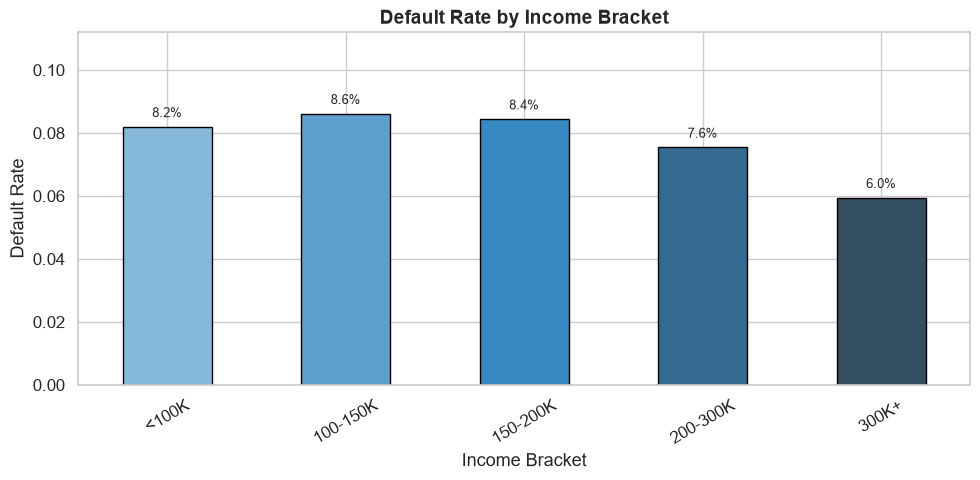

income_bracket
<100K       0.082028
100-150K    0.086188
150-200K    0.084470
200-300K    0.075503
300K+       0.059501
Name: TARGET, dtype: float64

In [4]:
income_bins = [0, 100_000, 150_000, 200_000, 300_000, float('inf')]
income_labels = ['<100K', '100-150K', '150-200K', '200-300K', '300K+']
df['income_bracket'] = pd.cut(df['AMT_INCOME_TOTAL'], bins=income_bins,
                               labels=income_labels, include_lowest=True)
rates1 = df.groupby('income_bracket', observed=False)['TARGET'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
rates1.plot(kind='bar', ax=ax, color=sns.color_palette('Blues_d', len(rates1)), edgecolor='black')
ax.set_title('Default Rate by Income Bracket', fontsize=14, fontweight='bold')
ax.set_xlabel('Income Bracket')
ax.set_ylabel('Default Rate')
ax.set_ylim(0, max(rates1.max() * 1.3, 0.01))
for i, v in enumerate(rates1):
    ax.text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()
rates1

## 4. Business Insight 2: Default Rate by Employment Length

Out[0]: 
bracket
<1y       0.109713
1-3y      0.110733
3-5y      0.096712
5-10y     0.073716
10-20y    0.055131
20y+      0.041823
Name: TARGET, dtype: float64


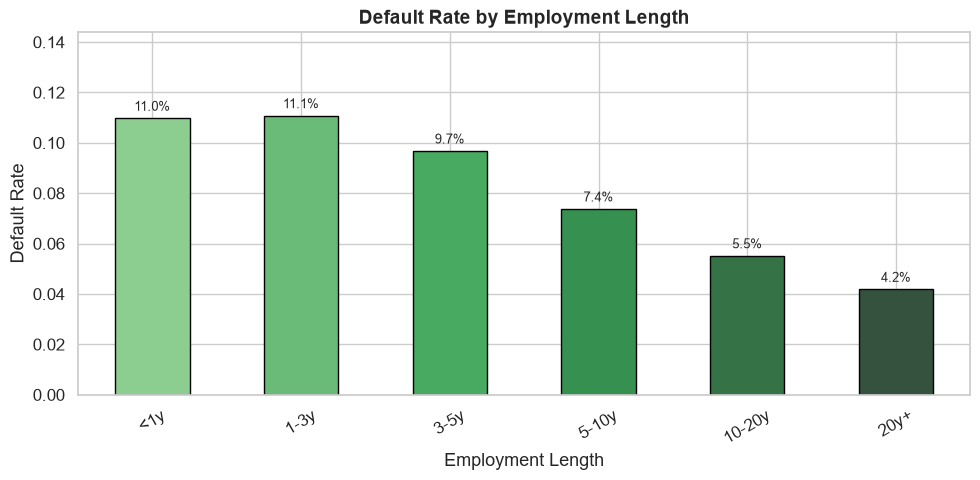

bracket
<1y       0.109713
1-3y      0.110733
3-5y      0.096712
5-10y     0.073716
10-20y    0.055131
20y+      0.041823
Name: TARGET, dtype: float64

In [5]:
temp_emp = df[['DAYS_EMPLOYED', 'TARGET']].dropna(subset=['DAYS_EMPLOYED']).copy()
temp_emp['employment_years'] = temp_emp['DAYS_EMPLOYED'].astype(float) / -365.25
emp_bins = [-1, 1, 3, 5, 10, 20, 100]
emp_labels = ['<1y', '1-3y', '3-5y', '5-10y', '10-20y', '20y+']
temp_emp['bracket'] = pd.cut(temp_emp['employment_years'], bins=emp_bins,
                              labels=emp_labels, include_lowest=True)
rates2 = temp_emp.groupby('bracket', observed=False)['TARGET'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
rates2.plot(kind='bar', ax=ax, color=sns.color_palette('Greens_d', len(rates2)), edgecolor='black')
ax.set_title('Default Rate by Employment Length', fontsize=14, fontweight='bold')
ax.set_xlabel('Employment Length')
ax.set_ylabel('Default Rate')
ax.set_ylim(0, max(rates2.max() * 1.3, 0.01))
for i, v in enumerate(rates2):
    ax.text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()
rates2

## 5. Business Insight 3: Default Rate by Education Type

Out[0]: 
NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / secondary special    0.089399
Incomplete higher                0.084850
Higher education                 0.053551
Academic degree                  0.018293
Name: TARGET, dtype: float64


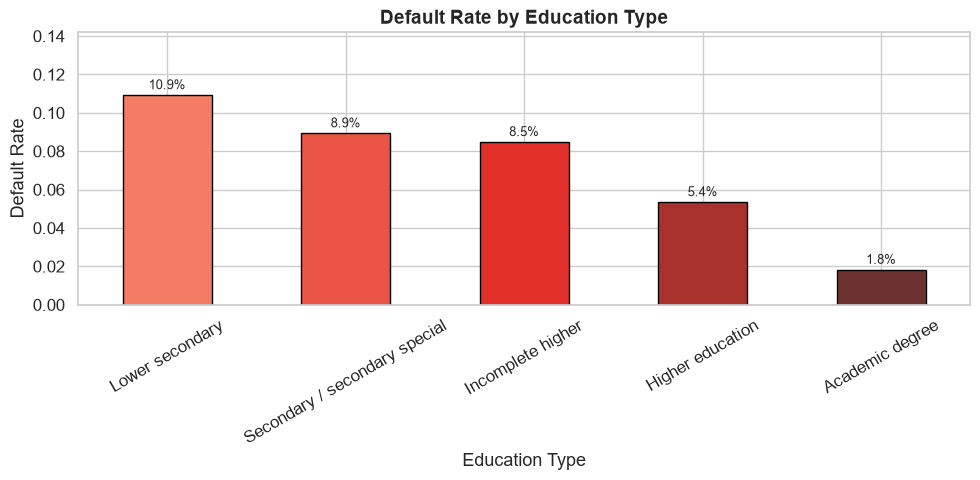

NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / secondary special    0.089399
Incomplete higher                0.084850
Higher education                 0.053551
Academic degree                  0.018293
Name: TARGET, dtype: float64

In [6]:
rates3 = df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
rates3.plot(kind='bar', ax=ax, color=sns.color_palette('Reds_d', len(rates3)), edgecolor='black')
ax.set_title('Default Rate by Education Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Education Type')
ax.set_ylabel('Default Rate')
ax.set_ylim(0, max(rates3.max() * 1.3, 0.01))
for i, v in enumerate(rates3):
    ax.text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()
rates3

## 6. Business Insight 4: Bureau Credit History vs Default

--- Bureau Active Credit Ratio ---
bracket
(-0.001, 0.2]    0.054337
(0.2, 0.375]     0.063684
(0.375, 0.6]     0.084633
(0.6, 1.0]       0.110109
Name: TARGET, dtype: float64
--- Bureau Avg DPD Ratio ---
bracket
(-0.001, 0.0102]    0.072418
(0.0102, 1.0]       0.108465
Name: TARGET, dtype: float64


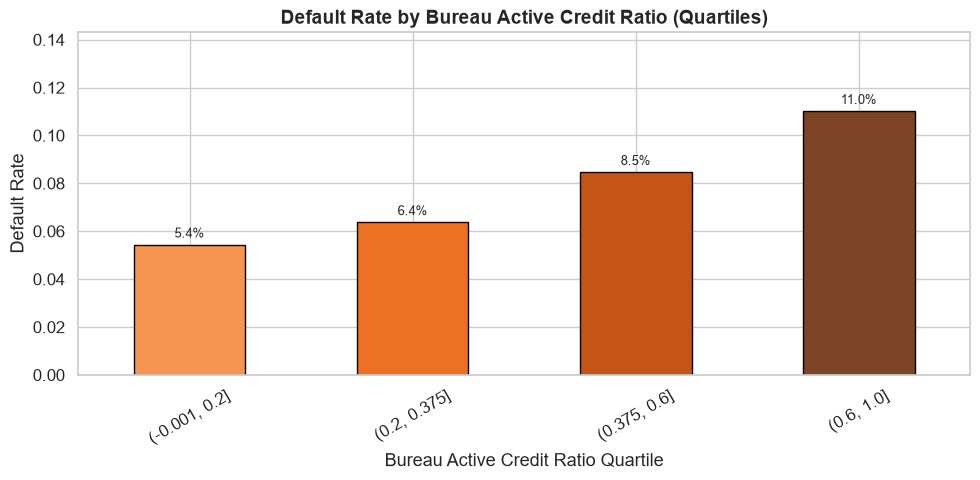

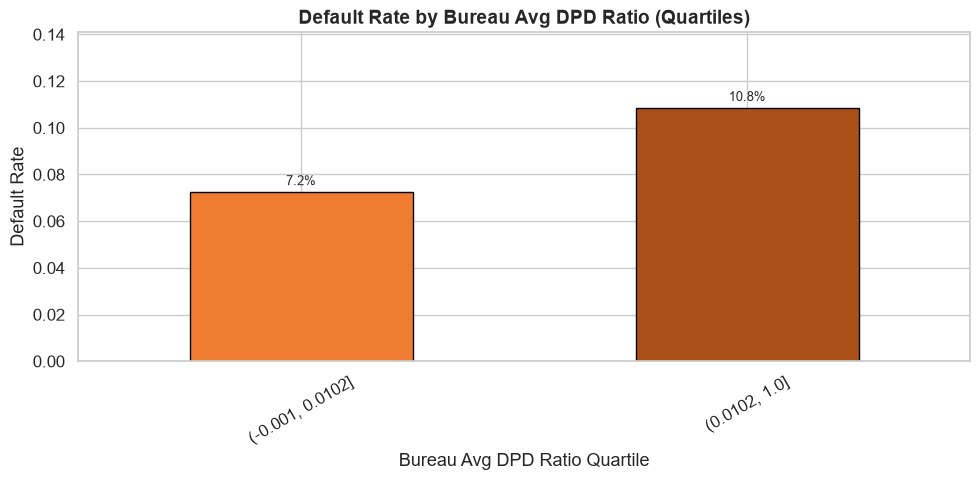

In [7]:
# 4a: Bureau Active Credit Ratio
temp4a = df[['bureau_credit_active_ratio', 'TARGET']].dropna(subset=['bureau_credit_active_ratio']).copy()
temp4a['bracket'] = pd.qcut(temp4a['bureau_credit_active_ratio'], q=4, duplicates='drop')
rates4a = temp4a.groupby('bracket', observed=False)['TARGET'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
rates4a.plot(kind='bar', ax=ax, color=sns.color_palette('Oranges_d', len(rates4a)), edgecolor='black')
ax.set_title('Default Rate by Bureau Active Credit Ratio (Quartiles)', fontsize=14, fontweight='bold')
ax.set_xlabel('Bureau Active Credit Ratio Quartile')
ax.set_ylabel('Default Rate')
ax.set_ylim(0, max(rates4a.max() * 1.3, 0.01))
for i, v in enumerate(rates4a):
    ax.text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()
print('--- Bureau Active Credit Ratio ---')
print(rates4a)

# 4b: Bureau Avg DPD Ratio
temp4b = df[['bureau_avg_dpd_ratio', 'TARGET']].dropna(subset=['bureau_avg_dpd_ratio']).copy()
temp4b['bracket'] = pd.qcut(temp4b['bureau_avg_dpd_ratio'], q=4, duplicates='drop')
rates4b = temp4b.groupby('bracket', observed=False)['TARGET'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
rates4b.plot(kind='bar', ax=ax, color=sns.color_palette('Oranges_d', len(rates4b)), edgecolor='black')
ax.set_title('Default Rate by Bureau Avg DPD Ratio (Quartiles)', fontsize=14, fontweight='bold')
ax.set_xlabel('Bureau Avg DPD Ratio Quartile')
ax.set_ylabel('Default Rate')
ax.set_ylim(0, max(rates4b.max() * 1.3, 0.01))
for i, v in enumerate(rates4b):
    ax.text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()
print('--- Bureau Avg DPD Ratio ---')
print(rates4b)

## 7. Business Insight 5: Repayment Delay vs Default

Out[0]: 
bracket
(-295.001, -16.5]    0.069614
(-16.5, -11.294]     0.072541
(-11.294, -8.0]      0.079966
(-8.0, -5.11]        0.086504
(-5.11, 1884.205]    0.100811
Name: TARGET, dtype: float64


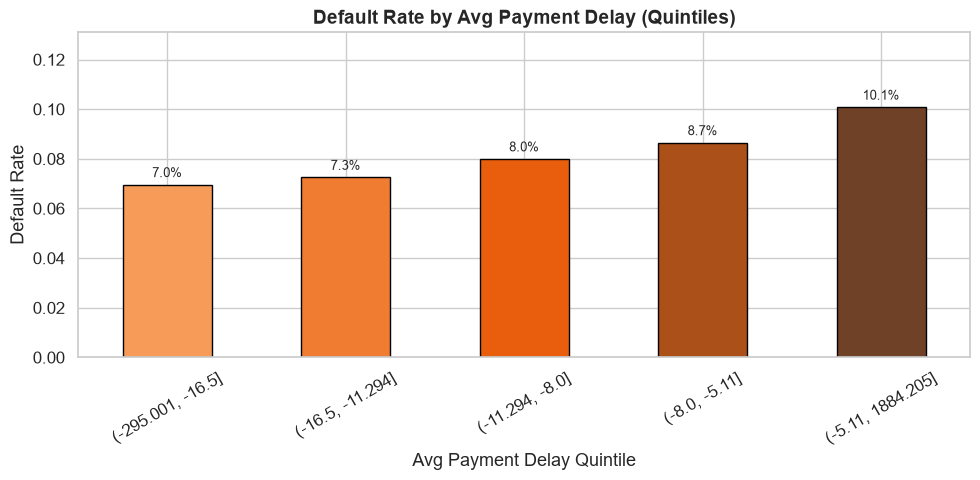

bracket
(-295.001, -16.5]    0.069614
(-16.5, -11.294]     0.072541
(-11.294, -8.0]      0.079966
(-8.0, -5.11]        0.086504
(-5.11, 1884.205]    0.100811
Name: TARGET, dtype: float64

In [8]:
temp5 = df[['avg_payment_delay', 'TARGET']].dropna(subset=['avg_payment_delay']).copy()
temp5['bracket'] = pd.qcut(temp5['avg_payment_delay'], q=5, duplicates='drop')
rates5 = temp5.groupby('bracket', observed=False)['TARGET'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
rates5.plot(kind='bar', ax=ax, color=sns.color_palette('Oranges_d', len(rates5)), edgecolor='black')
ax.set_title('Default Rate by Avg Payment Delay (Quintiles)', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Payment Delay Quintile')
ax.set_ylabel('Default Rate')
ax.set_ylim(0, max(rates5.max() * 1.3, 0.01))
for i, v in enumerate(rates5):
    ax.text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()
rates5

## 8. Business Insight 6: Credit Card Utilization vs Default

Out[0]: 
bracket
(-0.0858, 0.0]    0.054050
(0.0, 0.115]      0.056082
(0.115, 0.382]    0.071424
(0.382, 0.671]    0.098158
(0.671, 2.139]    0.153252
Name: TARGET, dtype: float64


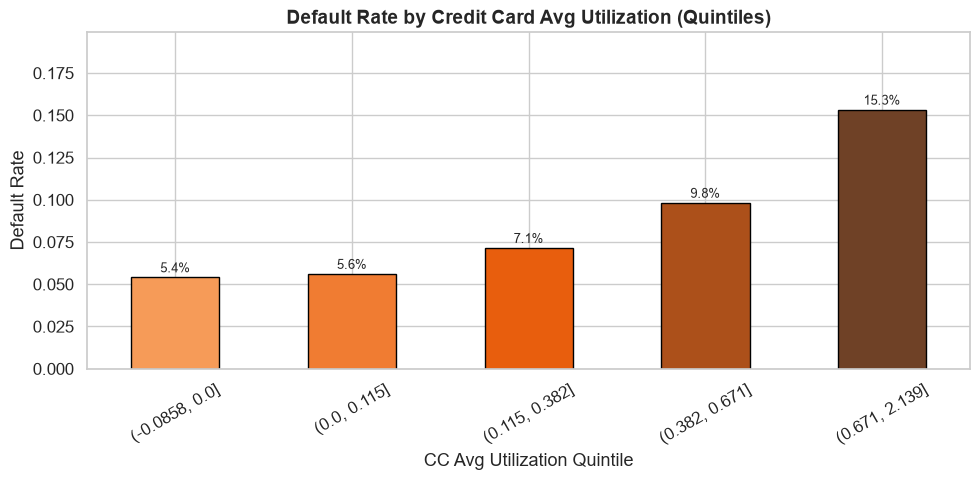

bracket
(-0.0858, 0.0]    0.054050
(0.0, 0.115]      0.056082
(0.115, 0.382]    0.071424
(0.382, 0.671]    0.098158
(0.671, 2.139]    0.153252
Name: TARGET, dtype: float64

In [9]:
temp6 = df[['cc_avg_utilization', 'TARGET']].dropna(subset=['cc_avg_utilization']).copy()
temp6['bracket'] = pd.qcut(temp6['cc_avg_utilization'], q=5, duplicates='drop')
rates6 = temp6.groupby('bracket', observed=False)['TARGET'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
rates6.plot(kind='bar', ax=ax, color=sns.color_palette('Oranges_d', len(rates6)), edgecolor='black')
ax.set_title('Default Rate by Credit Card Avg Utilization (Quintiles)', fontsize=14, fontweight='bold')
ax.set_xlabel('CC Avg Utilization Quintile')
ax.set_ylabel('Default Rate')
ax.set_ylim(0, max(rates6.max() * 1.3, 0.01))
for i, v in enumerate(rates6):
    ax.text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()
rates6

## 9. Business Insight 7: POS/Cash Loan DPD vs Default

Out[0]: 
bracket
(-0.001, 2622.078]    0.081608
Name: TARGET, dtype: float64


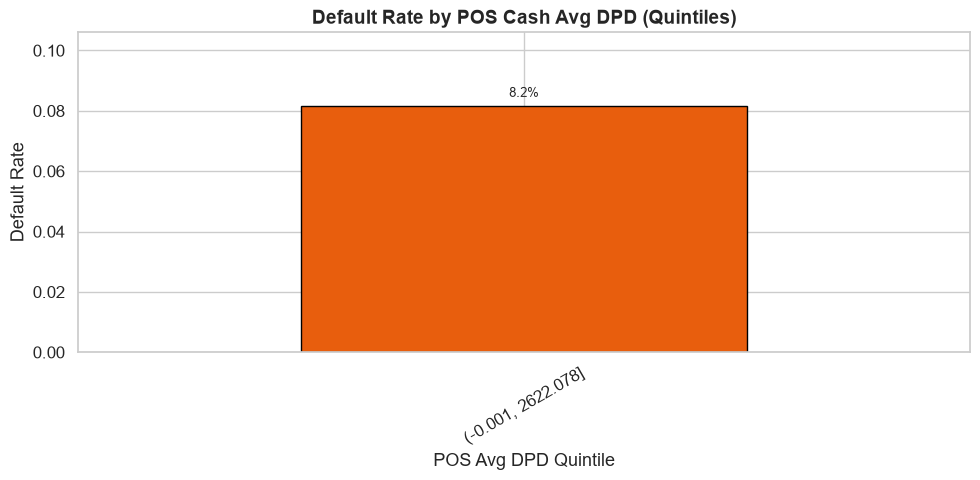

bracket
(-0.001, 2622.078]    0.081608
Name: TARGET, dtype: float64

In [10]:
temp7 = df[['pos_avg_dpd', 'TARGET']].dropna(subset=['pos_avg_dpd']).copy()
temp7['bracket'] = pd.qcut(temp7['pos_avg_dpd'], q=5, duplicates='drop')
rates7 = temp7.groupby('bracket', observed=False)['TARGET'].mean()

fig, ax = plt.subplots(figsize=(10, 5))
rates7.plot(kind='bar', ax=ax, color=sns.color_palette('Oranges_d', len(rates7)), edgecolor='black')
ax.set_title('Default Rate by POS Cash Avg DPD (Quintiles)', fontsize=14, fontweight='bold')
ax.set_xlabel('POS Avg DPD Quintile')
ax.set_ylabel('Default Rate')
ax.set_ylim(0, max(rates7.max() * 1.3, 0.01))
for i, v in enumerate(rates7):
    ax.text(i, v + 0.003, f'{v:.1%}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()
rates7

## 10. Feature Coverage Check
Confirm all 6 auxiliary tables contributed non-null engineered columns after the join.

In [11]:
engineered_prefixes = ['bureau_', 'prev_', 'pos_', 'cc_', 'avg_payment', 'max_payment', 'avg_underpayment', 'bb_']
engineered_cols = [c for c in df.columns if any(c.startswith(p) for p in engineered_prefixes)]
coverage = df[engineered_cols].isna().mean().sort_values(ascending=False)
print(coverage)

highly_null = coverage[coverage > 0.5]
if not highly_null.empty:
    print(f'\n⚠️  Columns with >50% null (may need special handling):')
    print(highly_null)
else:
    print('\n✓ All engineered columns have ≤50% null coverage.')

cc_avg_utilization            0.720218
cc_avg_balance                0.717392
cc_avg_dpd                    0.717392
cc_max_dpd                    0.717392
bureau_avg_dpd_ratio          0.700073
bureau_avg_credit_sum         0.143153
bureau_count                  0.143149
bureau_credit_active_ratio    0.143149
bureau_avg_days_credit        0.143149
bureau_total_overdue          0.143149
pos_max_dpd                   0.058752
pos_completed_ratio           0.058752
pos_avg_dpd                   0.058752
pos_contract_count            0.058752
prev_approved_ratio           0.053507
prev_app_count                0.053507
prev_avg_credit               0.053507
avg_underpayment              0.051627
avg_payment_delay             0.051627
max_payment_delay             0.051627
dtype: float64

⚠️  Columns with >50% null (may need special handling):
cc_avg_utilization      0.720218
cc_avg_balance          0.717392
cc_avg_dpd              0.717392
cc_max_dpd              0.717392
bureau_avg_dpd_r